# **AIRBNB DATA ANALYSIS (EDA)**

## **Overview**

Exploratory Data Analysis (EDA) on New York Airbnb data to uncover trends and patterns in rental listings.

## **Tools Used**
- Python
- Jupyter notebook
- Pandas
- Matplotlib
- Seaborn

## **Objectives**

- Analyze room types, prices, and availability across different neighborhoods.
- Understand listing patterns.
- Detect potential outliers in prices.
- Provide recommendations for guests and hosts based on insights.

## **Dataset**

The dataset contains 20,765 entries and 22 features, including:

- id: Unique identifier for each listing
- name: Title of the Airbnb listing
- host_name: Name of the host
- neighborhood_group: Group (borough) where the listing is located
- latitude/longitude: Geolocation of listings
- price: Nightly rental price
- room_type: Type of accommodation (e.g., entire home, private room)
- number_of_reviews: Total reviews for the listing
- availability_365: Number of available days in the year
- rating - Average rating out of 5 for the listings


### **1. Importing required libraries** 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

%matplotlib inline

### **2. Loading dataset**

In [2]:
df = pd.read_csv('./datasets.csv')

### **3. Initial exploration**

In [3]:
# Checking a sample of the dataset
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
0,1.312228e+06,Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.683710,-73.964610,Private room,55.0,...,20/12/15,0.03,1.0,0.0,0.0,No License,5,1,1,Not specified
1,4.527754e+07,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144.0,...,01/05/23,0.24,139.0,364.0,2.0,No License,4.67,2,1,1
2,9.710000e+17,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187.0,...,18/12/23,1.67,1.0,343.0,6.0,Exempt,4.17,1,2,1
3,3.857863e+06,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,...,17/09/23,1.38,2.0,363.0,12.0,No License,4.64,1,1,1
4,4.089661e+07,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751120,-73.978600,Entire home/apt,85.0,...,03/12/23,0.24,133.0,335.0,3.0,No License,4.91,Studio,1,1


In [4]:
# Checking the columns (features) available in the dataset
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license', 'rating',
       'bedrooms', 'beds', 'baths'],
      dtype='str')

In [5]:
# Checking datatypes and non-null values of each column in the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20770 entries, 0 to 20769
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20770 non-null  float64
 1   name                            20770 non-null  str    
 2   host_id                         20770 non-null  int64  
 3   host_name                       20770 non-null  str    
 4   neighbourhood_group             20770 non-null  str    
 5   neighbourhood                   20763 non-null  str    
 6   latitude                        20763 non-null  float64
 7   longitude                       20763 non-null  float64
 8   room_type                       20763 non-null  str    
 9   price                           20736 non-null  float64
 10  minimum_nights                  20763 non-null  float64
 11  number_of_reviews               20763 non-null  float64
 12  last_review                     20763 non-n

In [6]:
# Statistical summary of the numerical clolumns in the dataset
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,beds
count,2.077000e+04,2.077000e+04,20763.000000,20763.000000,20736.000000,20763.000000,20763.000000,20763.000000,20763.000000,20763.000000,20763.000000,20770.000000
mean,3.033858e+17,1.749049e+08,40.726821,-73.939179,187.714940,28.558493,42.610605,1.257589,18.866686,206.067957,10.848962,1.723592
std,3.901221e+17,1.725657e+08,0.060293,0.061403,1023.245124,33.532697,73.523401,1.904472,70.921443,135.077259,21.354876,1.211993
min,2.595000e+03,1.678000e+03,40.500314,-74.249840,10.000000,1.000000,1.000000,0.010000,1.000000,0.000000,0.000000,1.000000
25%,2.707260e+07,2.041184e+07,40.684159,-73.980755,80.000000,30.000000,4.000000,0.210000,1.000000,87.000000,1.000000,1.000000
50%,4.992852e+07,1.086990e+08,40.722890,-73.949597,125.000000,30.000000,14.000000,0.650000,2.000000,215.000000,3.000000,1.000000
75%,7.220000e+17,3.143997e+08,40.763106,-73.917475,199.000000,30.000000,49.000000,1.800000,5.000000,353.000000,15.000000,2.000000
max,1.050000e+18,5.504035e+08,40.911147,-73.713650,100000.000000,1250.000000,1865.000000,75.490000,713.000000,365.000000,1075.000000,42.000000


### **4. Data cleaning**

In [7]:
# Dealing with null values in the dataset

# Checking null values
df.isnull().sum()

# Dropping all null values, since there is no logical way to subsititute their values
df.dropna(inplace=True)

In [8]:
# Dealing with duplicate rows in the dataset

# Checking duplicate rows
df.duplicated().sum()

# Dropping duplicate rows
df.drop_duplicates(inplace=True)

In [9]:
# Removing price column outliers

# Since the max value is 100,000.00 and the 75% quartile value is 199.00, we will remove any price values above 1,000 to avoid skewed visualizations.
df = df[df['price'] < 1000]

In [10]:
# Cleaning rating column
def to_num(string):
    if string == 'No rating' or string == 'New ':
        return 0.0
    else:
        return float(string)
df['rating'] = df['rating'].apply(to_num) 

### **5. Data Analysis**

Text(0.5, 1.0, 'Price distribution')

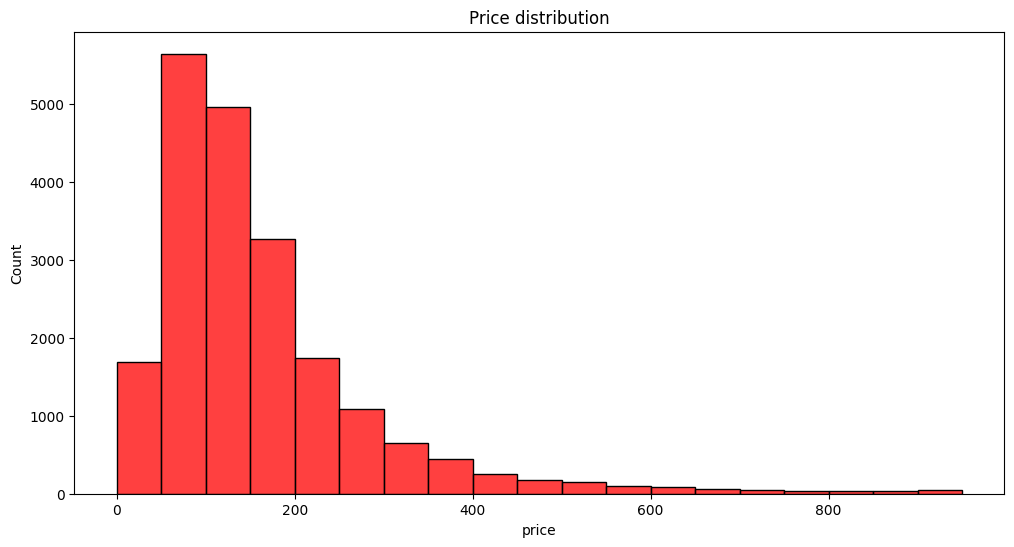

In [11]:
# Price distribution
x_values = np.arange(0, 1000, 50)

plt.figure(figsize=(12, 6))
sns.histplot(df['price'], bins=x_values, color='red')
plt.title('Price distribution')


#### Observations
- Majority of the listings were priced between $50 - $200.

Text(0.5, 1.0, '365 days availability distribution')

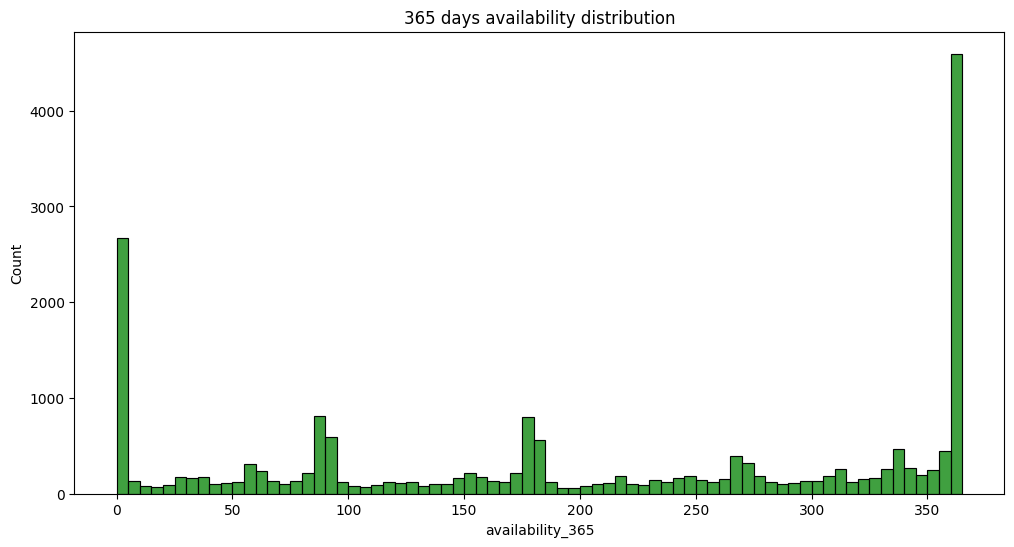

In [12]:
# 365 days availability distribution
x_values = np.arange(0, 370, 5)

plt.figure(figsize=(12, 6))
sns.histplot(df['availability_365'], bins = x_values, color='green')
plt.title('365 days availability distribution')


#### Observations
- We can see maximum listings are available for 365 days of the year.

In [13]:
# Average price in each neighbourhood groups

avgs = df.groupby(by='neighbourhood_group')['price'].mean().to_dict()
print('Average price in each neighbouring group')
for key, value in avgs.items():
    print(f"Neighbourhood group: {key}, average price: ${value:.2f}")

Average price in each neighbouring group
Neighbourhood group: Bronx, average price: $107.05
Neighbourhood group: Brooklyn, average price: $153.24
Neighbourhood group: Manhattan, average price: $193.29
Neighbourhood group: Queens, average price: $120.89
Neighbourhood group: Staten Island, average price: $115.74


In [14]:
# FEATURE ENGINEERING

# Price per bed
df['price_per_bed'] = df['price']/df['beds']

# Overall popularity score of listing (number_of_reviews * rating)
df['popularity_score'] = df['number_of_reviews']*df['rating']


In [15]:
# Average price per bed in each neighbourhood groups
avgs2 = df.groupby(by='neighbourhood_group')['price_per_bed'].mean().to_dict()
print('Average price per bed in each neighbouring group')
for key, value in avgs2.items():
    print(f"Neighbourhood group: {key}, average price: ${value:.2f}")


Average price per bed in each neighbouring group
Neighbourhood group: Bronx, average price: $73.74
Neighbourhood group: Brooklyn, average price: $98.84
Neighbourhood group: Manhattan, average price: $133.76
Neighbourhood group: Queens, average price: $76.10
Neighbourhood group: Staten Island, average price: $67.27


Text(0.5, 1.0, 'Price dependency on neighbourhood and room type')

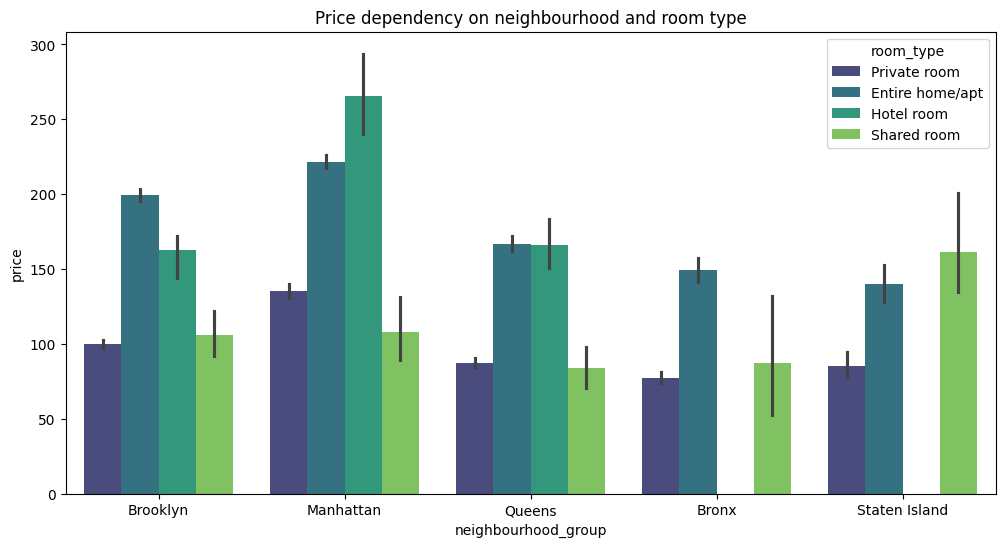

In [16]:
# Price dependency on neighbourhood and room type
plt.figure(figsize=(12,6))
sns.barplot(data = df, x='neighbourhood_group', y='price', hue='room_type', palette='viridis')
plt.title('Price dependency on neighbourhood and room type')

#### Observations

- Manhattan is the most expensive
- Entire home/apartment is consistently the costliest room type
- Bronx and Staten Island are comparatively cheaper

Text(0.5, 1.0, 'Relation between Price and Popularity score')

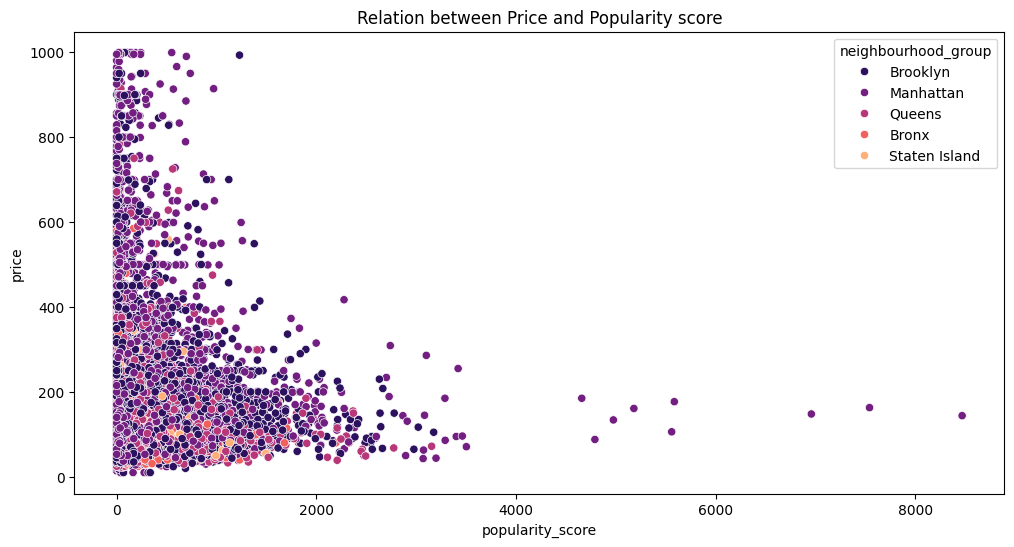

In [17]:
# Relation between Price and Popularity score
plt.figure(figsize=(12,6))
sns.scatterplot(data = df, x= 'popularity_score', y = 'price', hue='neighbourhood_group', palette='magma')
plt.title('Relation between Price and Popularity score')

#### Observations
- Higher popularity score does not necessarily mean higher price.
- Majority of listings have popularity scores below 2000.
- Expensive listings (above 500) appear mostly at lower popularity levels.

In [18]:
# Geographical Distribution of Airbnb Listing for each room type
px.scatter_map(df, lat="latitude", lon="longitude", zoom=10, height=600, opacity=0.3, color='room_type')

#### Geographical Distribution of Airbnb Listing for each room type
![Geographical distribution of Airbnb over New York](./images/geographical_distribution.png)

#### Observations
- Manhattan has the highest listing density, followed by Brooklyn
- Entire home/apartment dominates
- Queens and Bronx have fewer listings
- Hotel and shared rooms are rare

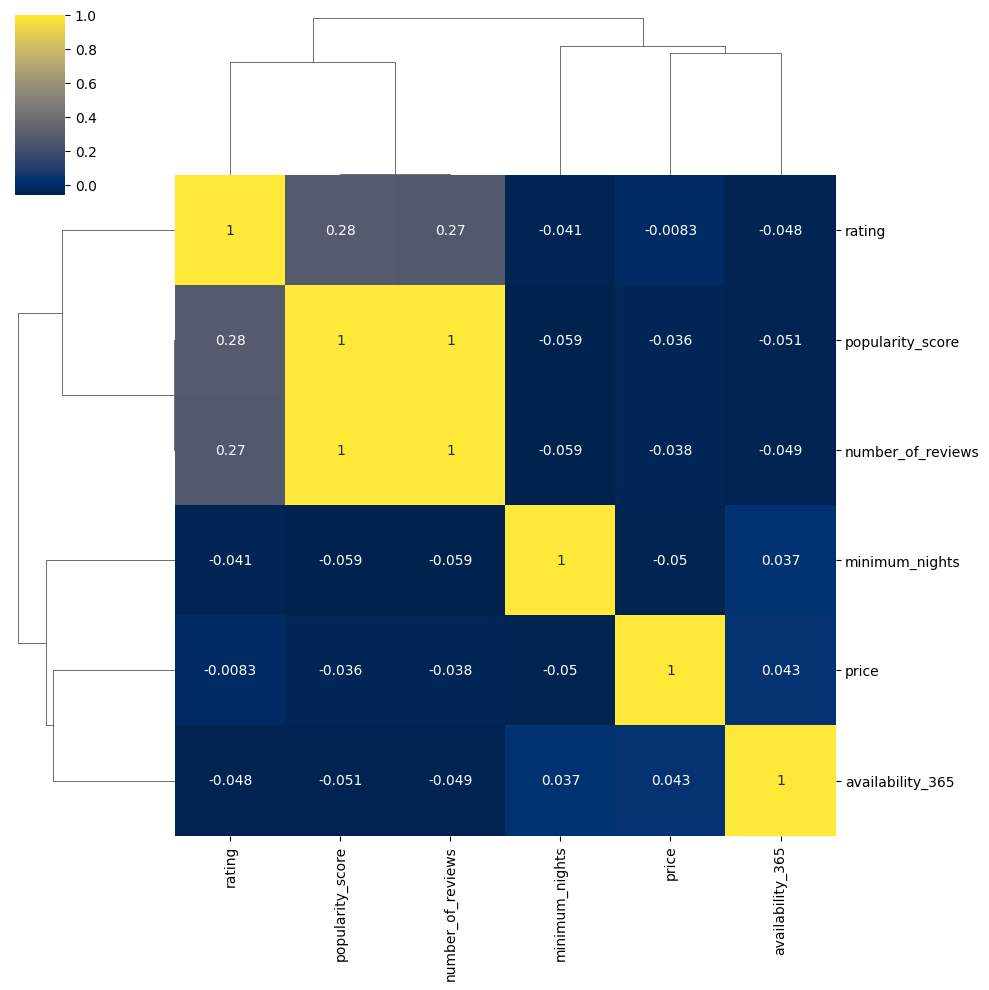

In [21]:
 # Price–Demand–Quality relationships
cols = ['price', 'popularity_score', 'rating', 'availability_365', 'minimum_nights', 'number_of_reviews']
corr = df[cols].corr()
sns.clustermap(corr, annot=True, cmap = 'cividis')

#### Observations

- Rating has a weak positive correlation with popularity and reviews
- Price, minimum nights, and availability show almost no correlation with other variables

## Key Findings and Insights

- Price Trends:

    - Manhattan has the most expensive listings, followed by Brooklyn.
    - Entire homes/apartments cost significantly more than private or shared rooms.

- Room Type Distribution:

    - Entire homes/apartments are the most common, but private rooms offer budget-friendly options.

- Outliers in Price:

    - Few listings priced at $10,000+ were detected, indicating the need to filter such extreme values.

- Availability Patterns:

    - Listings with high availability tend to have lower prices and more reviews, likely due to better guest experience.

## Future work

- Use machine learning to predict prices based on room type and location.
- Perform sentiment analysis on reviews to better understand guest experiences.
- Create an interactive dashboard using business intelligence tools.

## Conclusion
This project offers valuable insights into the New York Airbnb market, helping both guests and hosts make informed decisions. By using EDA techniques, we identified key trends and developed actionable recommendations. Future improvements can involve advanced analytics and predictive modeling to further enhance the findings.